#ML4Net - Lab 2

## Team members

Àlex Roger Moya (NIA 254095) | Pau Martínez Carrión (NIA 285580)

## Description

In this lab, you will implement an ML model that detects congestion in Wi-Fi networks. In particular, you will desing and implement a supervised learning model (e.g., linear regression, multi-layer perceptron, neural network), which you will train using a dataset that was generated using the ns-3 simulator.

Each row in the dataset is organized as (x1, x2, ..., x26, y1, y2, ..., y26, s, r, l), where:

* `x1, x2..., x26, y1, y2, ..., y26` represent the histogram of the Inter-Frame Space (IFS) values for M frames that accessed the medium in a 60 seconds observation sample.
  * `x26` represents the maximum IFS duration (in ms) in the considered M frames whereas `x1` is `x26`/26
  * The remaining `xi` values are buckets at uniform spacing between `x1` and `x26`.
  * For i>1, the values of `yi` represent the IFS histogram count (in percentage) for a corresponding bucket interval between `xi`-1 and `xi`.
  * In the case of `y1`, the bucket interval is between 0 and `x1`
* `s` is the average IFS duration (in ms)
* `r` is the percentage of frame collisions
* `l` is the label, where 1 indicates that the network is saturated, and 0, that it is not

Original dataset: https://ieee-dataport.org/documents/dataset-identification-saturated-and-unsaturated-wi-fi-networks

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 21 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

2. Download the dataset

In [ ]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip

--2026-05-22 13:24:08--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip [following]
--2026-05-22 13:24:08--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1803279 (1.7M) [application/zip]
Saving to: ‘dataset_Lab2.zip’

dataset_Lab2.zip    100%[===================>]   1.72M  --.-KB/s    in 0.06s   

2026-05-22 13:24:09 (26.9 MB/

3. Define the main path of the code

In [ ]:
mypath="drive/MyDrive/AAX/Lab2"

4. Extract the source code to the destination folder

In [ ]:
mkdir $mypath; cp dataset_Lab2.zip $mypath; cd $mypath; unzip dataset_Lab2.zip

## Visualizing the data




       0       1       2       3       4       5       6       7       8   \
0  0.0065  0.0130  0.0195  0.0260  0.0325  0.0390  0.0455  0.0520  0.0585   
1  0.0263  0.0526  0.0789  0.1052  0.1316  0.1579  0.1842  0.2105  0.2368   
2  0.0176  0.0352  0.0528  0.0704  0.0881  0.1057  0.1233  0.1409  0.1585   
3  0.0222  0.0444  0.0666  0.0888  0.1110  0.1332  0.1554  0.1776  0.1998   
4  0.0189  0.0379  0.0568  0.0758  0.0947  0.1137  0.1326  0.1516  0.1705   

       9   ...      45      46      47      48      49      50      51  \
0  0.0650  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
1  0.2631  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
2  0.1761  ...  0.0316  0.0368  0.0312  0.0312  0.0316  0.0299  0.0304   
3  0.2220  ...  0.0316  0.0307  0.0312  0.0000  0.0360  0.0364  0.0304   
4  0.1895  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   

       52      53  54  
0  0.0604  0.9960   1  
1  0.0604  0.9960   1  
2  0.0604  0.9957   

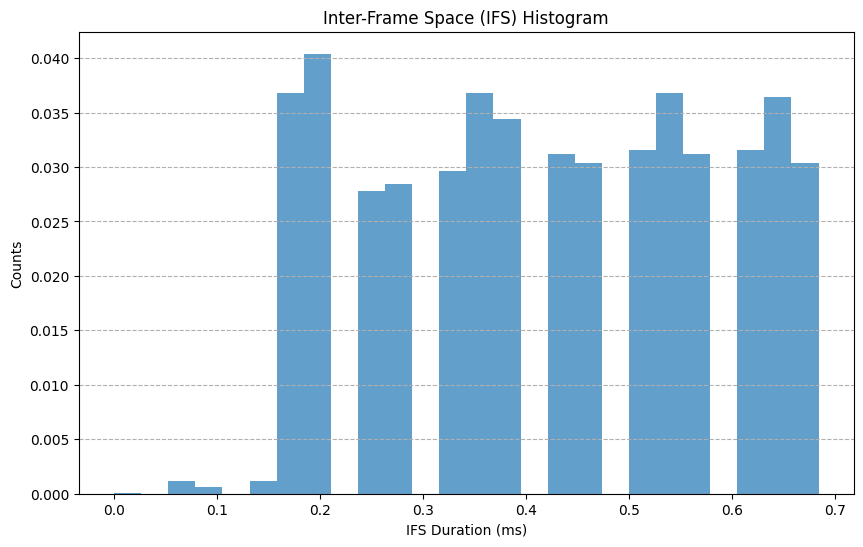

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ifs_histogram(data_row):
    """
    Plots the Inter-Frame Space (IFS) histogram from a single row of the dataset.

    Args:
        data_row (list or numpy.ndarray): A list or array representing a single row
                                          in the format (x1, ..., x26, y1, ..., y26, s, r, l).
    """

    # Get IFS values and the corresponding counts
    x_values = np.array(data_row[:26])
    y_counts = np.array(data_row[26:52])

    # Calculate the bin edges based on x_values
    bin_edges = [0] + list(x_values)

    # Create the histogram plot
    plt.figure(figsize=(10, 6))
    plt.bar(bin_edges[:-1], y_counts, width=np.diff(bin_edges)[0], align='edge', alpha=0.7)

    # Add labels and title
    plt.xlabel("IFS Duration (ms)")
    plt.ylabel("Counts")
    plt.title("Inter-Frame Space (IFS) Histogram")
    plt.grid(axis='y', linestyle='--')

    # Show the plot
    plt.show()

# Example usage

# -> Read the data file
file_name = mypath + '/train_data.csv'
train_data_df = pd.read_csv(file_name, header=None)
print(train_data_df.head())

# -> Get a sample from the dataset and plot it
row_index = 1
sample_data = train_data_df.iloc[row_index].values
plot_ifs_histogram(sample_data)

## EXERCISES

**Imports**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

### Exercise 1:
Define an approach for training and validating the model you are going to train with the proposed data. Then, perform the split accordingly.

*In order to avoid overfitting (when a model memorizes the exact pattern of the test data, and doesn't respond well to new data), we define an 80% train and 20% validation split. This ensures the MLP can learn features of Wi-Fi congestion from the majority of the data (80%), while the remaining unseen data (20%) provides a measure of the model's ability to generalize to new network states, thus preventing overfitting.*

In [6]:
# (response to exercise 1)
X = np.array(train_data_df.iloc[:, :-1])
y = np.array(train_data_df.iloc[:, -1])
values_train, values_val, labels_train, labels_val = train_test_split(X, y, train_size=0.8, shuffle=True) #We shuffle the data to ensure the model sees both 0 and 1 examples in all sets.

### Exercise 2:

Define your ML model, so that it can be called for training and test. Examples of approaches that you could use (but not limited to):

*   Logistic Regression
*   K-Nearest Neighbors (KNN)
*   Decision Trees or Random Forests
*   Convolutional Neural Network (CNN)

**Chosen model**

The chosen model to train is a Multi Layer Perceptron (MLP). In an MLP, each neuron calculates a weighted sum of its inputs and applies an activation function (like ReLU or Sigmoid) to determine its output. Mathematically, for a single neuron, that looks like:$$y = \sigma \left( \sum_{i=1}^{n} w_i x_i + b \right)$$
Where:
- $w$ represents the weights.
- $x$ represents your features.
- $b$ is the bias.
- $\sigma$ is the activation function.


**Why MLP?**

Although a Linear Classifier is also a great option, if the boundary between "saturated" and "not saturated" isn't a straight line, or isn't clear enough, it will fail to classify. On the other hand, a Multi Layer Perceptron, is more flexible, because of its hidden layers and activation functions, it can bend and twist to fit complex, non-linear boundaries.

The data is structured as a histogram, and histograms represent a distribution. The relationship between $y_1$ and $y_{26}$ is what matters. Hidden layers in an MLP allow the model to discover these interactions without us having to manually define them.

Nevertheless, it requires more tuning, with hyperparameters,than other models like a decision tree, but handles the non-linear nature of histograms perfectly.

### Exercise 3:

Define the hyperparameters that you will use to train the model.

In [7]:
# (response to exercise 3)
lr = 0.001
num_epochs = 500
activation = 'relu'
hidden_layer_sizes = (128,64)

We defined four main hyperparameters:

- `hidden_layer_sizes = (128,64)`:
    - This defines the architecture of the model. There's two hidden layers: the first has 128 neurons and the second has 64.
    - Since there are 54 input features, starting with 128 neurons gives the model enough capacity to look for patterns. Dropping to 64 in the second layer helps the model summarize those patterns into a final decision.
- `lr = 0.001` (Learning rate):
    - This is the step size the model take when adjusting its weights to fix errors.
    - 0.001 is considered the sweet spot for most problems. If it were larger (e.g., 0.1), the model would learn too aggressively and likely overshoot, but if it were smaller, the training would take too long to finish.
- `num_epochs = 500`:
    - This is the total number of times the model will read through the entire training dataset.
    - 500 passes ensure the model has enough practice to find the best possible weights. In most network simulations, the error converges before 500, but this ensures the model doesn't stop learning before converging.
- `activation = 'relu'`:
    - The switch that decides if a neuron should fire. It uses the mathematical function $f(x) = \max(0, x)$
    - ReLU is the industry standard because it is fast and prevents the model from stalling during training.

### Exercise 4:
Train the model and show the procedure (e.g., evolution of the training/validation loss).

Despite defining the hyperparameters based on the standards, we didn't want tojust guess the best settings, so we tested them to find out how the model behaves. We varied three mechanics:

- Learning Rates (0.001 vs. 0.005 vs. 0.01): To find the optimal step size. A rate too small takes too long to learn, but a rate too large will overshoot and cause chaotic jumps.

- Activation Functions (ReLU vs. Logistic): To test how well the network handles complex, non-linear Wi-Fi data. We wanted to see if the classical Logistic (Sigmoid) function would suffer from the "vanishing gradient problem" compared to modern ReLU.

- Solvers (SGD vs. Adam): To compare a baseline, constant-speed optimizer (SGD) against an automatic optimizer (Adam) which dynamically changes speeds for every single weight.

In [8]:
from sklearn.metrics import log_loss

**Test 1: SGD + ReLU (LR = 0.001)**

- Purpose: Test a conservative, cautious learning rate using standard SGD.

- Analysis: The curves are smooth, but the descent is too slow. At 500 epochs, the lines are still going downward and have not converged.

- Conclusion: Underfitting, the model ran out of time before it could reach the bottom of the error valley.

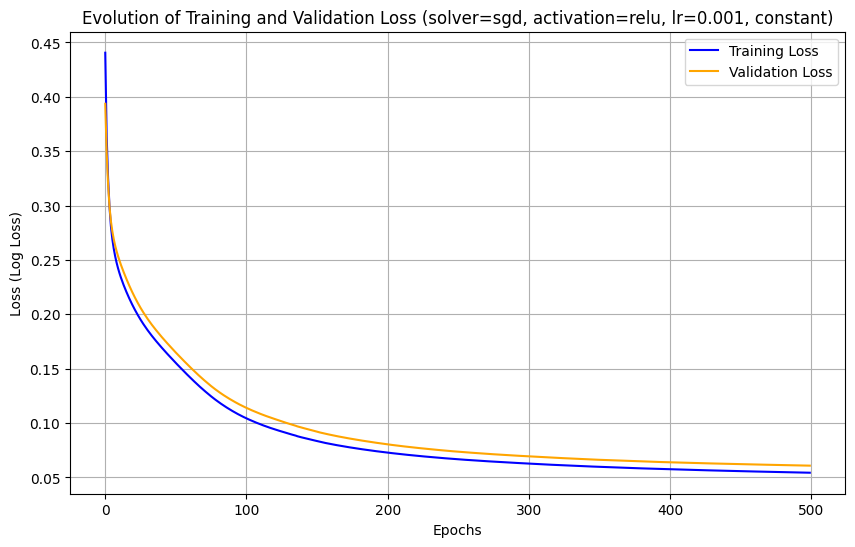

In [46]:
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=activation,
                    solver='sgd', learning_rate_init=lr, random_state=42, learning_rate='constant')

classes = np.unique(labels_train)
train_loss = []
val_loss = []

# Manual training loop for 500 epochs
for i in range(num_epochs):
    mlp.partial_fit(values_train, labels_train, classes=classes)

    # Calculate Training Loss
    train_loss.append(mlp.loss_)

    # Calculate Validation Loss
    val_probs = mlp.predict_proba(values_val)
    val_loss.append(log_loss(labels_val, val_probs))

# Plotting the Procedure
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title("Evolution of Training and Validation Loss (solver=sgd, activation=relu, lr=0.001, constant)")
plt.xlabel("Epochs")
plt.ylabel("Loss (Log Loss)")
plt.legend()
plt.grid(True)
plt.show()

**Test 2: SGD + ReLU (LR = 0.005)**

- Purpose: Increase the learning rate slightly to speed up convergence.

- Analysis: A perfect curve. The training and validation lines follow each other seamlessly without any gap.

- Conclusion: Excellent stability. This shows generalization with zero noise, though the final error floor is restricted by SGD.

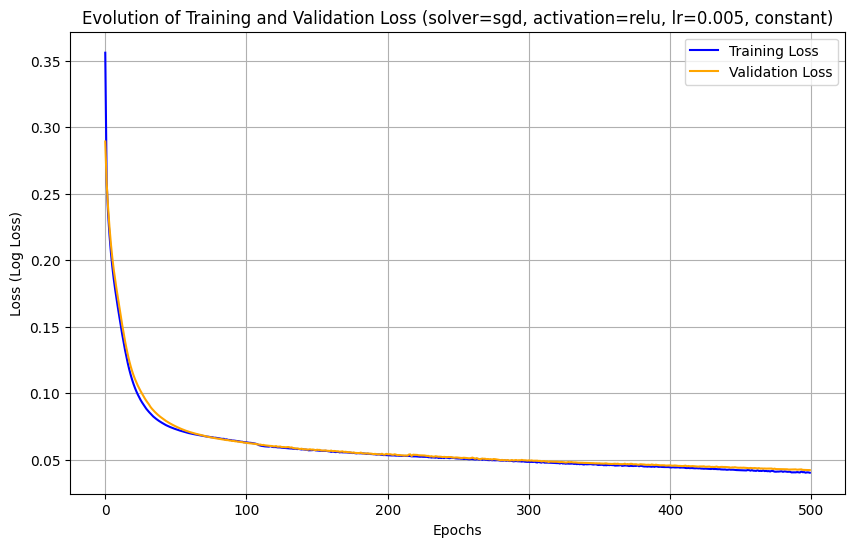

In [47]:
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=activation,
                    solver='sgd', learning_rate_init=0.005, random_state=42, learning_rate='constant')

classes = np.unique(labels_train)
train_loss = []
val_loss = []

# Manual training loop for 500 epochs
for i in range(num_epochs):
    mlp.partial_fit(values_train, labels_train, classes=classes)

    # Calculate Training Loss
    train_loss.append(mlp.loss_)

    # Calculate Validation Loss
    val_probs = mlp.predict_proba(values_val)
    val_loss.append(log_loss(labels_val, val_probs))

# Plotting the Procedure
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title("Evolution of Training and Validation Loss (solver=sgd, activation=relu, lr=0.005, constant)")
plt.xlabel("Epochs")
plt.ylabel("Loss (Log Loss)")
plt.legend()
plt.grid(True)
plt.show()

**Test 3: SGD + ReLU (LR = 0.01)**

- Purpose: Test an aggressive step size with SGD.

- Analysis: The model plummets fast in the first 50 epochs, but between epochs 100 and 250, the validation line develops sharp oscillations. The step size was too large, causing the model to bounce before settling down.

- Conclusion: Unstable convergence. The learning rate is right on the edge of being too high.

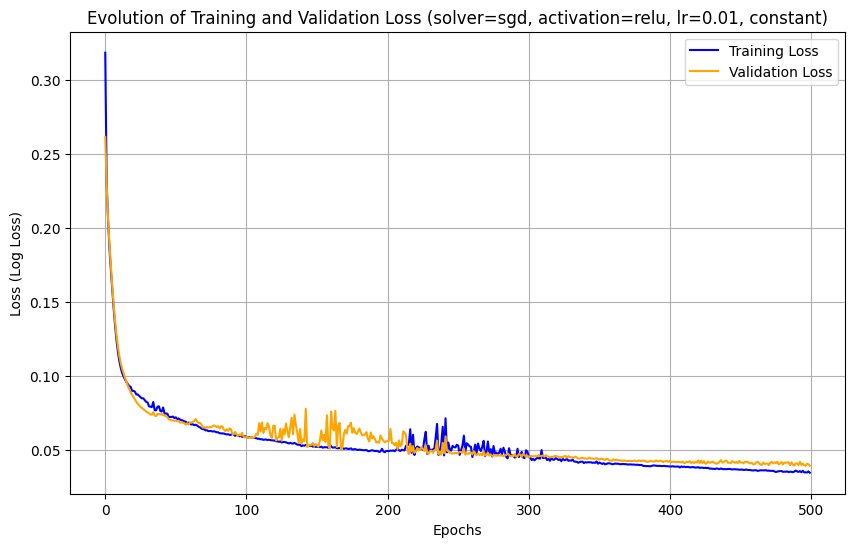

In [48]:
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=activation,
                    solver='sgd', learning_rate_init=0.01, random_state=42, learning_rate='constant')

classes = np.unique(labels_train)
train_loss = []
val_loss = []

# Manual training loop for 500 epochs
for i in range(num_epochs):
    mlp.partial_fit(values_train, labels_train, classes=classes)

    # Calculate Training Loss
    train_loss.append(mlp.loss_)

    # Calculate Validation Loss
    val_probs = mlp.predict_proba(values_val)
    val_loss.append(log_loss(labels_val, val_probs))

# Plotting the Procedure
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title("Evolution of Training and Validation Loss (solver=sgd, activation=relu, lr=0.01, constant)")
plt.xlabel("Epochs")
plt.ylabel("Loss (Log Loss)")
plt.legend()
plt.grid(True)
plt.show()

**Test 4: SGD + Logistic (LR = 0.005)**

- Purpose: Swap ReLU out for Logistic (Sigmoid) to compare internal node activation.

- Analysis: While the curve is smooth, it flattens out too early at a much higher loss value (~0.07) than its ReLU alternative (~0.04).

- Conclusion: The curves of the logistic function saturated, killing off the gradients and stopping the model from learning deeper patterns.

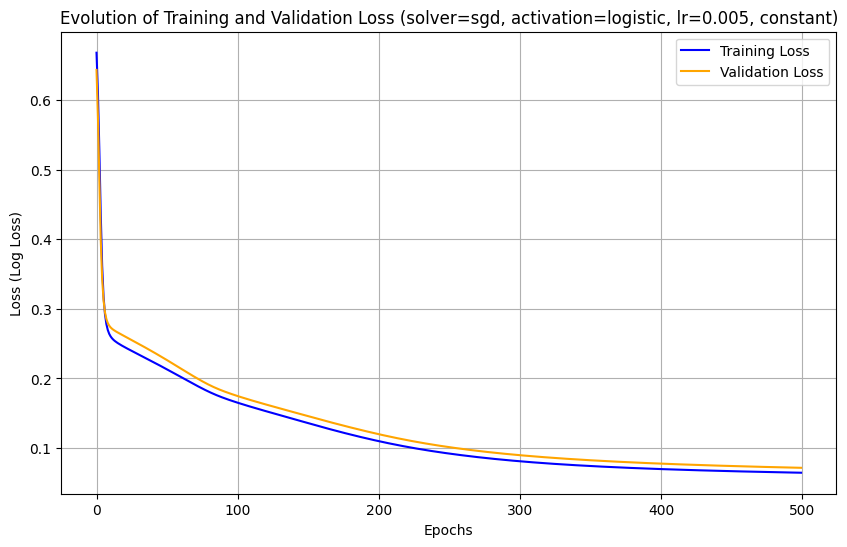

In [49]:
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='logistic',
                    solver='sgd', learning_rate_init=0.005, random_state=42, learning_rate='constant')

classes = np.unique(labels_train)
train_loss = []
val_loss = []

# Manual training loop for 500 epochs
for i in range(num_epochs):
    mlp.partial_fit(values_train, labels_train, classes=classes)

    # Calculate Training Loss
    train_loss.append(mlp.loss_)

    # Calculate Validation Loss
    val_probs = mlp.predict_proba(values_val)
    val_loss.append(log_loss(labels_val, val_probs))

# Plotting the Procedure
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title("Evolution of Training and Validation Loss (solver=sgd, activation=logistic, lr=0.005, constant)")
plt.xlabel("Epochs")
plt.ylabel("Loss (Log Loss)")
plt.legend()
plt.grid(True)
plt.show()

**Test 5: Adam + Logistic (LR = 0.005)**

- Purpose: See if the smart Adam optimizer can improve the Logistic function.

- Analysis: The graph shows an irregular pattern where learning stalls, suddenly drops, and experiences a destabilization spike around epoch 400, and finishes with chaotic oscillations.

- Conclusion: Highly Unstable. Adam’s adaptive math clashes with the flattening gradients of the Logistic function.

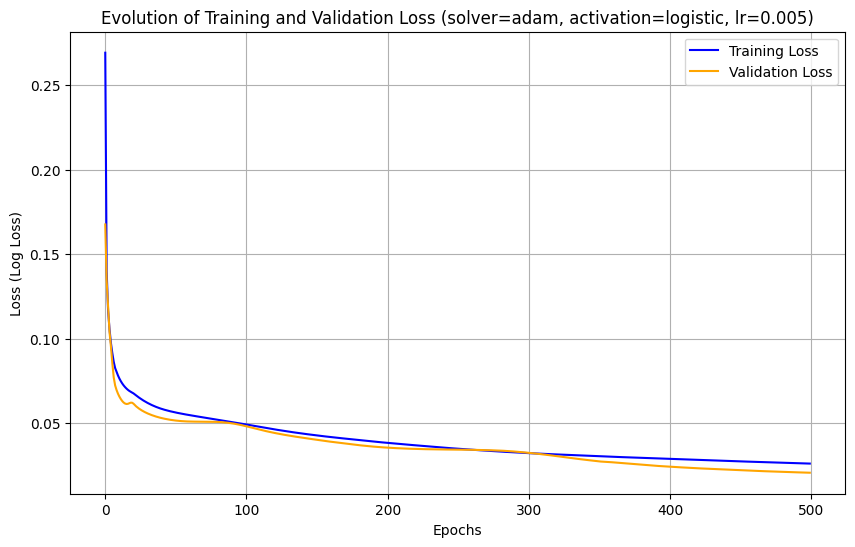

In [10]:
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='logistic',
                    solver='adam', learning_rate_init=0.005, random_state=42)

classes = np.unique(labels_train)
train_loss = []
val_loss = []

# Manual training loop for 500 epochs
for i in range(num_epochs):
    mlp.partial_fit(values_train, labels_train, classes=classes)

    # Calculate Training Loss
    train_loss.append(mlp.loss_)

    # Calculate Validation Loss
    val_probs = mlp.predict_proba(values_val)
    val_loss.append(log_loss(labels_val, val_probs))

# Plotting the Procedure
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title("Evolution of Training and Validation Loss (solver=adam, activation=logistic, lr=0.005)")
plt.xlabel("Epochs")
plt.ylabel("Loss (Log Loss)")
plt.legend()
plt.grid(True)
plt.show()

**Test 6: Adam + ReLU (LR = 0.005)**

- Purpose: Apply an adaptive solver to our ReLU/0.005 test.

- Analysis: This configuration achieves the deepest plunge. Training loss hits the lowest value (~0.015), and validation drops to ~0.03. The tiny oscillations in the lines are the visual representation of Adam aggressively tweaking independent parameters to find the lowest possible error.

- Conclusion: Maximum Optimization. It finds a deeper, superior solution that regular SGD missed.

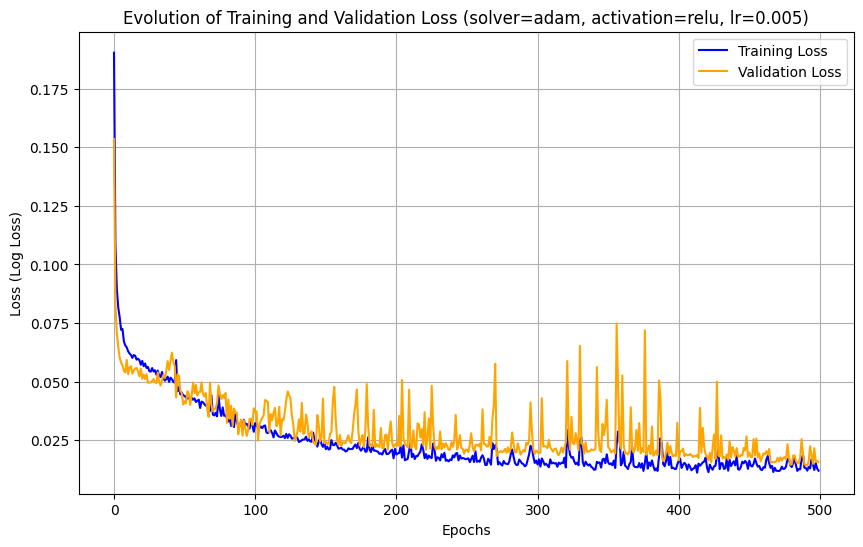

In [11]:
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=activation,
                    solver='adam', learning_rate_init=0.005, random_state=42)

classes = np.unique(labels_train)
train_loss = []
val_loss = []

# Manual training loop for 500 epochs
for i in range(num_epochs):
    mlp.partial_fit(values_train, labels_train, classes=classes)

    # Calculate Training Loss
    train_loss.append(mlp.loss_)

    # Calculate Validation Loss
    val_probs = mlp.predict_proba(values_val)
    val_loss.append(log_loss(labels_val, val_probs))

# Plotting the Procedure
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title("Evolution of Training and Validation Loss (solver=adam, activation=relu, lr=0.005)")
plt.xlabel("Epochs")
plt.ylabel("Loss (Log Loss)")
plt.legend()
plt.grid(True)
plt.show()

For the final deployment we used configuration 6 (Solver=Adam, Activation=ReLU, Learning Rate=0.005). Justification:

- Absolute error minimization: In classification tasks, our priority is reducing log-loss to maximize predictive metrics like precision and recall. Configuration 5 cleared out error better than any other script, getting the lowest training error near 0.015.

- No signs of overfitting: Even though Adam introduced variance/noise into the validation line, the gap between the training and validation curves remained close and parallel all the way to the last epoch. The validation line never drifted upward, which ensures strong generalization.

- Efficiency: It harvested the bulk of its accuracy within the first 75 epochs.

### Exercise 5:

Select and define the most appropriate evaluation metric(s). Discuss the appropriateness of your evaluation metrics for the binary classification problem we are considering.

Validation Accuracy: 99.45%

Classification Report:
                   precision    recall  f1-score   support

Not Saturated (0)       0.99      1.00      0.99      1975
    Saturated (1)       1.00      0.99      0.99      2025

         accuracy                           0.99      4000
        macro avg       0.99      0.99      0.99      4000
     weighted avg       0.99      0.99      0.99      4000



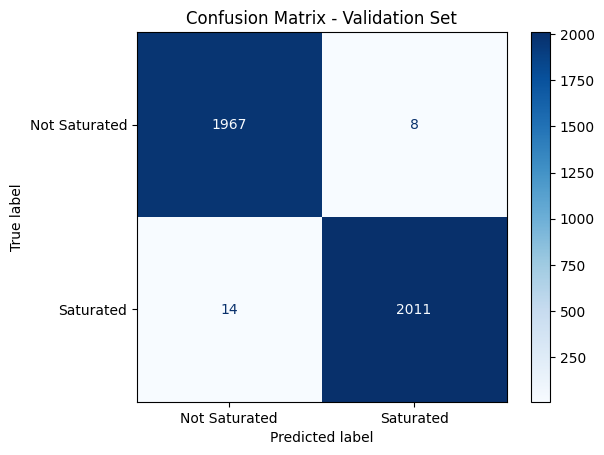

In [12]:
# 1. Get predictions on the validation set
predictions = mlp.predict(values_val)

# 2. Accuracy
print(f"Validation Accuracy: {accuracy_score(labels_val, predictions):.2%}")

# 3. Full classification report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(labels_val, predictions, target_names=['Not Saturated (0)', 'Saturated (1)']))

# 4. Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(labels_val, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Saturated', 'Saturated'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Validation Set')
plt.show()

**Explanation:** The Validation Accuracy is 99.45%, which means that the model correctly classified 99.45% of the 4000 validation samples.

Out of 4000 samples, it only made 22 mistakes total: 8 false alarms (said the network was "Saturated" when it was actually fine) and 14 missed detections (said it was "Not Saturated" when it was actually experiencing congestion). Missing real saturation is typically worse than a false alarm in network management practice, but failing to detect only 14 out of 2025 true saturated cases is an exceptionally strong result.

Both classes achieve an F1-score of 0.99, proving that the model performs equally well at detecting congestion and non-congestion without showing any bias toward either class. 

### Exercise 6:

Evaluate your trained model on the test set, using the evaluation metrics that you have proposed. Remember that the test data should have not been seen by the model, so that we can properly estimate of its generalization capabilities.

Test Accuracy: 94.80%

Classification Report (Test Set):
                   precision    recall  f1-score   support

Not Saturated (0)       1.00      0.89      0.94       240
    Saturated (1)       0.91      1.00      0.95       260

         accuracy                           0.95       500
        macro avg       0.95      0.95      0.95       500
     weighted avg       0.95      0.95      0.95       500



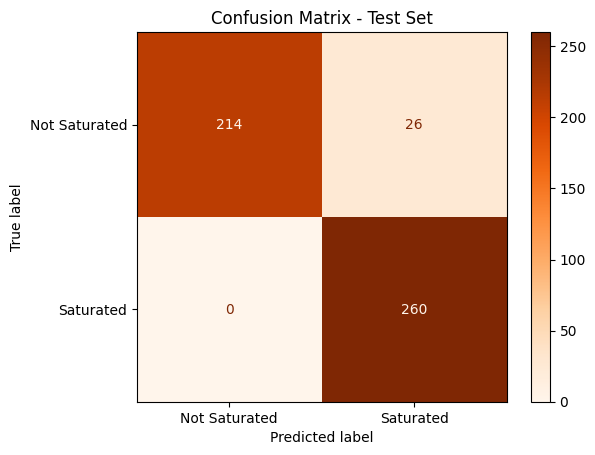

In [ ]:
# 1. we load the test data
test_file = mypath + '/test_data.csv'
test_data_df = pd.read_csv(test_file, header=None)

# 2. Split features and labels
X_test = np.array(test_data_df.iloc[:, :-1])
y_test = np.array(test_data_df.iloc[:, -1])

# 3. Predict on the test set (model has never seen this data)
test_predictions = mlp.predict(X_test)

# 4. Evaluate with the same metrics as Exercise 5
print(f"Test Accuracy: {accuracy_score(y_test, test_predictions):.2%}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, test_predictions, target_names=['Not Saturated (0)', 'Saturated (1)']))

# 5. Confusion Matrix on test set
cm_test = confusion_matrix(y_test, test_predictions)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Not Saturated', 'Saturated'])
disp_test.plot(cmap='Oranges')
plt.title('Confusion Matrix - Test Set')
plt.show()

**Explanation:** The model achieved 94.80% accuracy on the test set, which is about 4.65% lower than the validation accuracy (99.45%).

This small drop is completely normal and expected, as the test set contains data the model has never seen before, making it the most honest measure of real performance.
The most remarkable result here is that the model made 0 missed detections, it caught every single saturated case. The trade-off is 26 false alarms (flagging congestion when the network was fine), but in a real Wi-Fi network that's the safer error to make: better to trigger congestion control unnecessarily than to ignore real congestion.

Overall, the model generalizes well to new environments. Validation and test accuracy are close to each other, which means the model actually learned the pattern and didn't just memorize the training data.